# PART 5: Regression Analysis

## Issues in Linear Regression Analysis and Logistic Regression

## Linear Regression - not that easy (Anscombe Dataset)

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
anscombe = pd.read_csv("anscombe.csv", index_col = "dataset", usecols = ["dataset", "x", "y"])

In [73]:
anscombe

,x,y
dataset,,
I,10.0,8.04
I,8.0,6.95
I,13.0,7.58
I,9.0,8.81
I,11.0,8.33
I,14.0,9.96
I,6.0,7.24
I,4.0,4.26
I,12.0,10.84


In [74]:
anscombe.index.unique()

Index(['I', 'II', 'III', 'IV'], dtype='object', name='dataset')

In [75]:
anscombe_grouped = anscombe.groupby(anscombe.index).agg({"x": ["count","mean", "std"], "y": ["mean", "std"]})
anscombe_grouped

x                        y          
        count mean       std      mean       std
dataset                                         
I          11  9.0  3.316625  7.500909  2.031568
II         11  9.0  3.316625  7.500909  2.031657
III        11  9.0  3.316625  7.500000  2.030424
IV         11  9.0  3.316625  7.500909  2.030579

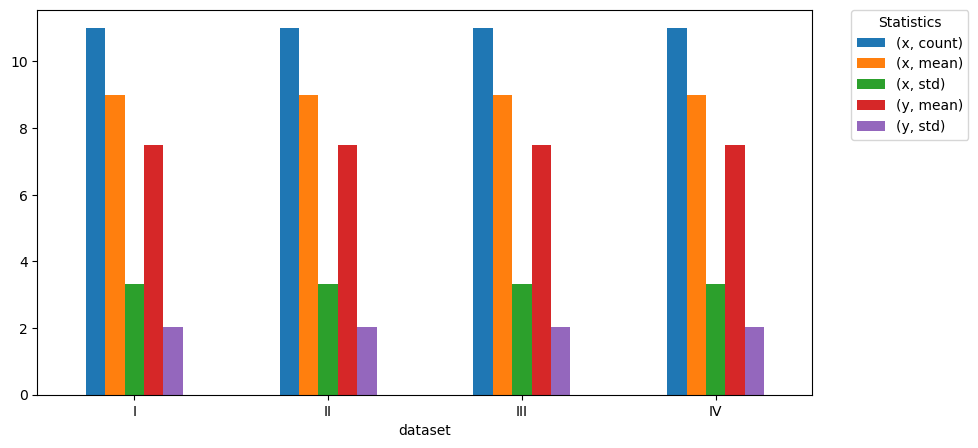

In [76]:
anscombe_grouped.plot.bar(figsize = (10,5),
                         subplots = False)

plt.legend(bbox_to_anchor = (1.05,1) ,  
           loc = "upper left", 
           borderaxespad = 0, 
           title = "Statistics")

plt.xticks(rotation = 0)
plt.show()

In [77]:
anscombe.loc["I"].corr()

,x,y
x,1.000000,0.816421
y,0.816421,1.000000


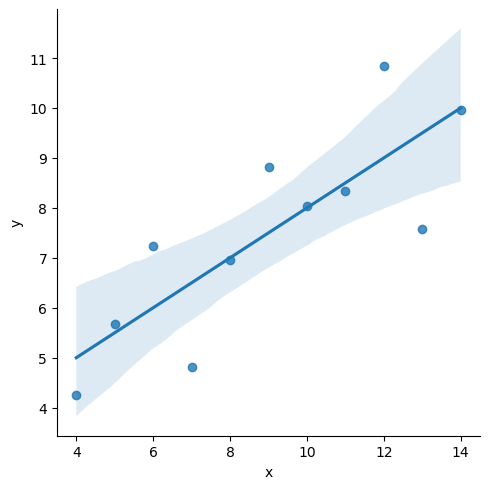

In [78]:
sns.lmplot(x = "x", y = "y", data = anscombe.loc["I"])
plt.show()

In [79]:
anscombe.loc["II"].corr()

,x,y
x,1.000000,0.816237
y,0.816237,1.000000


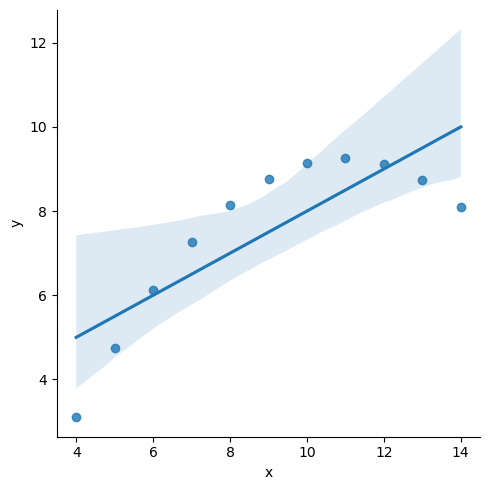

In [80]:
sns.lmplot(x = "x", y = "y", data = anscombe.loc["II"] , logistic = False)
plt.show()

In [81]:
anscombe.loc["III"].corr()

,x,y
x,1.000000,0.816287
y,0.816287,1.000000


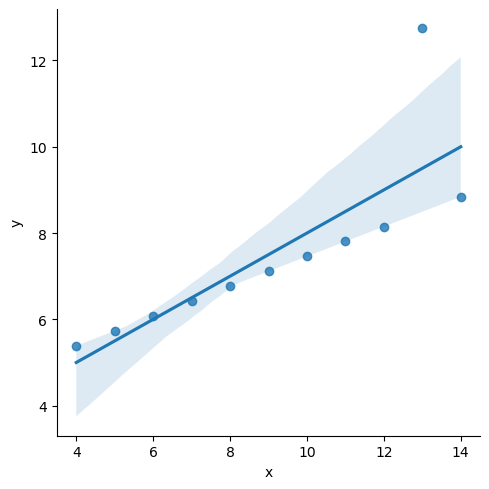

In [82]:
sns.lmplot(x = "x", y = "y", data = anscombe.loc["III"])
plt.show()

In [83]:
anscombe.loc["IV"].corr()

,x,y
x,1.000000,0.816521
y,0.816521,1.000000


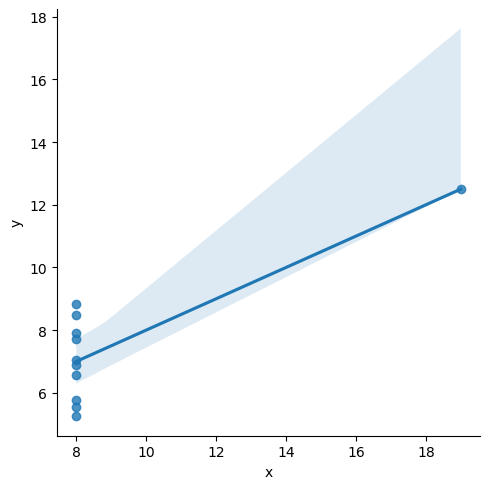

In [84]:
sns.lmplot(x = "x", y = "y", data = anscombe.loc["IV"])
plt.show()

In [85]:
for i in ["I", "II", "III", "IV"]:
    print(np.polyfit(x = anscombe.loc[i].x, y = anscombe.loc[i].y, deg = 1))

[0.50009091 3.00009091]
[0.5        3.00090909]
[0.49972727 3.00245455]
[0.49990909 3.00172727]


### Detecting and handling Outliers (Part 1)

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols

In [87]:
df = pd.read_csv("movies_prep.csv")

In [88]:
df

,title,budget,revenue,vote_average,popularity,belongs_to_collection
0,Ca$h,7.0,0.046488,6.0,9.107829,False
1,Leap Year,19.0,29.922472,6.5,7.432311,False
2,Morning Glory,40.0,58.785180,6.1,10.771255,False
3,Devil,10.0,33.583175,5.8,7.094276,False
4,Tooth Fairy,48.0,112.462508,5.2,6.744680,True
...,...,...,...,...,...,...
1564,Resident Evil: The Final Chapter,40.0,312.242626,5.9,0.755710,True
1565,Railroad Tigers,50.0,102.205175,6.2,3.798504,False
1566,Dangal,10.4,310.000000,8.0,8.792104,False
1567,Live by Night,108.0,22.678555,6.2,19.943930,False


In [89]:
df.describe()

,budget,revenue,vote_average,popularity
count,1569.000000,1569.000000,1569.000000,1569.000000
mean,37.890643,115.641690,6.246399,11.069328
std,50.097848,208.966838,0.857069,18.488345
min,0.000001,0.000001,0.000000,0.016219
25%,6.200000,5.728213,5.700000,6.091224
50%,18.700000,35.692920,6.300000,8.896679
75%,45.000000,122.513057,6.800000,12.572718
max,380.000000,2068.223624,9.000000,547.488298


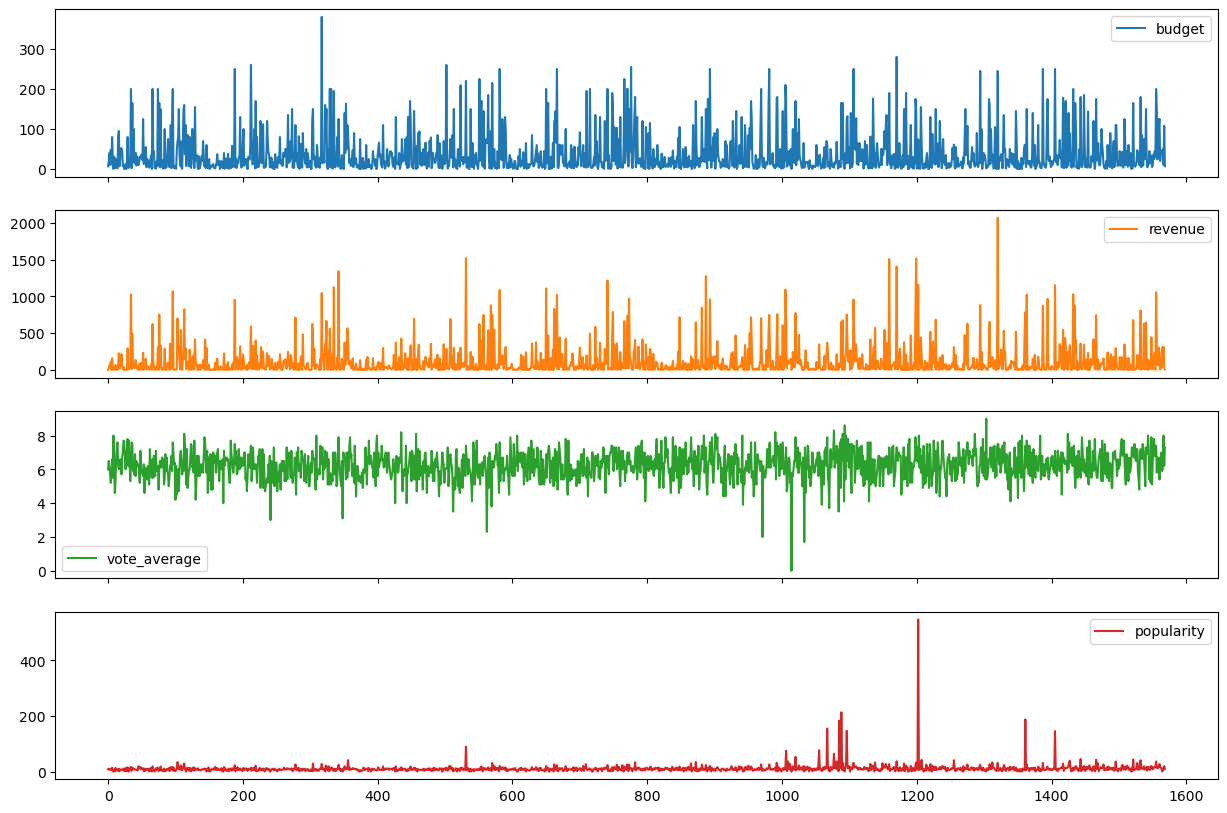

In [90]:
df.plot(figsize = (15, 10), subplots = True)
plt.show()

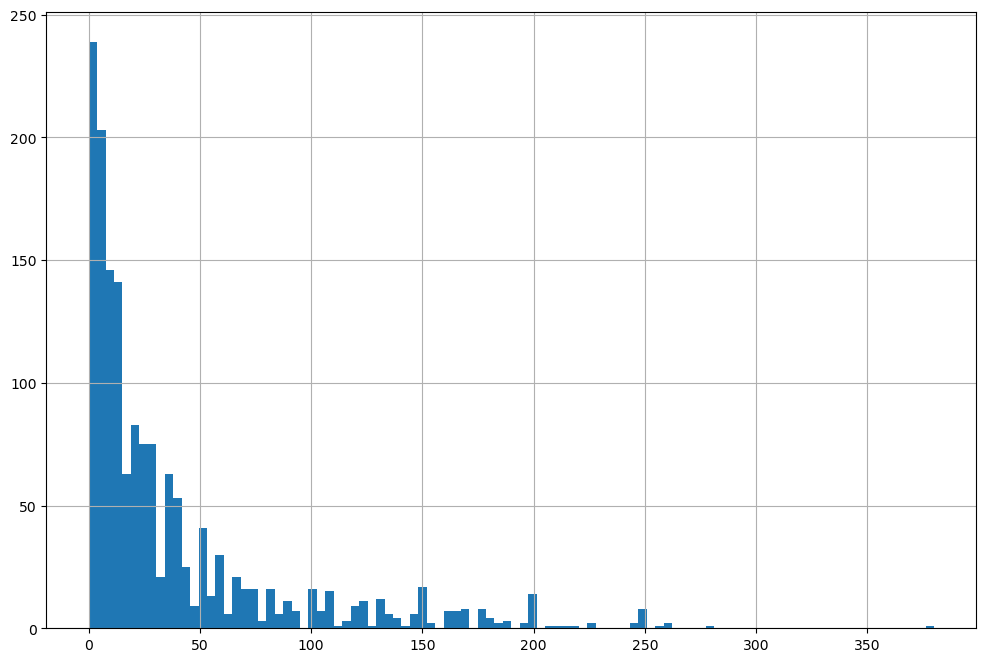

In [91]:
plt.figure(figsize = (12, 8))
df.budget.hist(bins = 100)
plt.show()

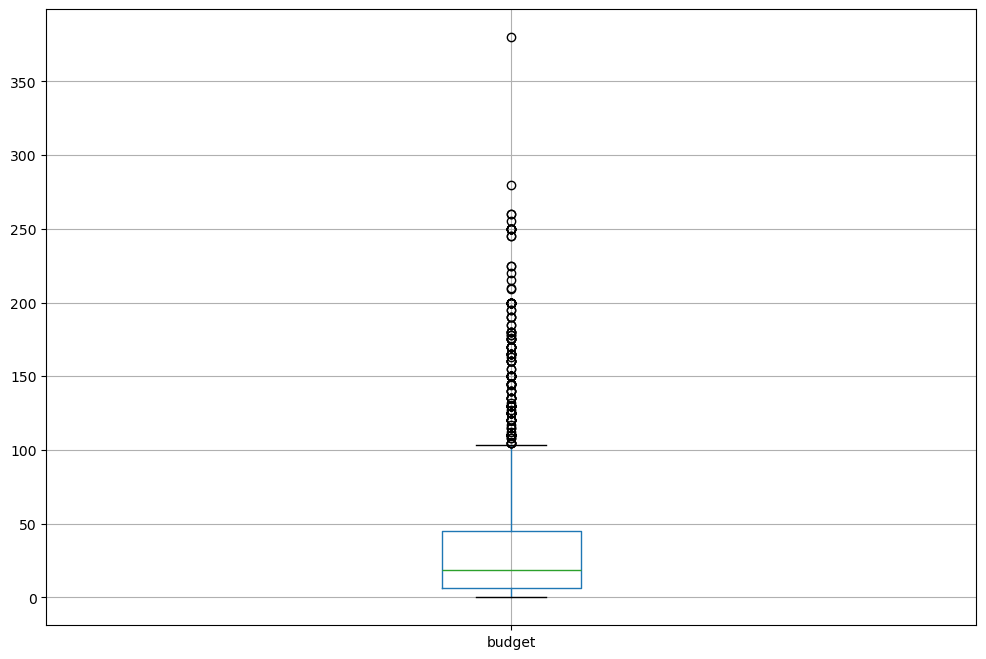

In [92]:
plt.figure(figsize = (12, 8))
df.boxplot(column = "budget", rot ="horizontal")
plt.show()

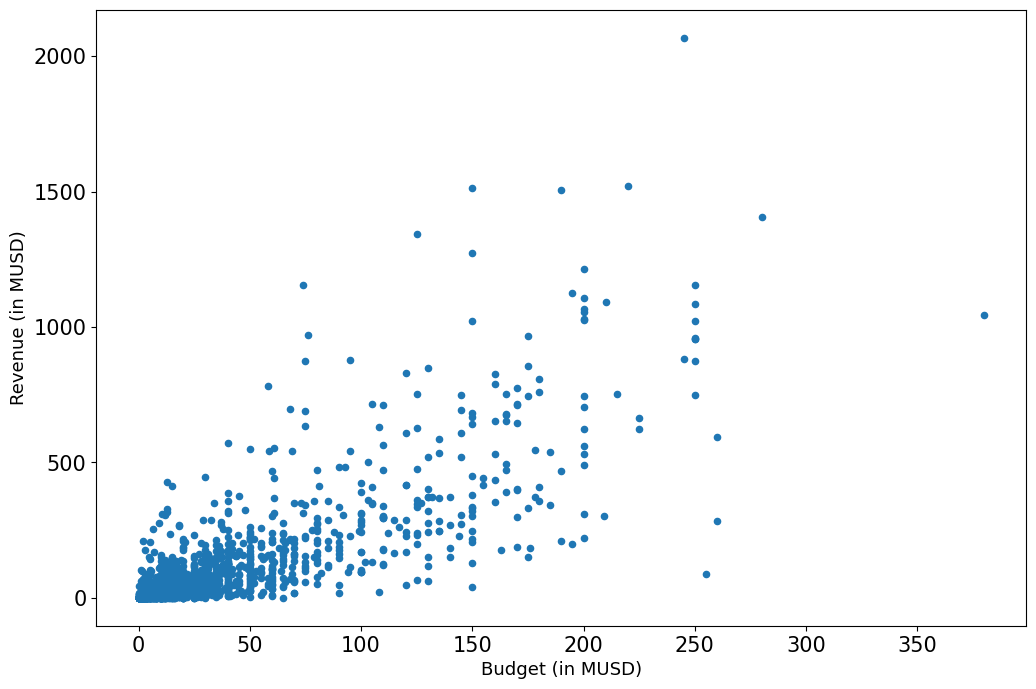

In [93]:
df.plot(kind = "scatter", x = "budget", y = "revenue", figsize = (12, 8), fontsize = 15)
plt.xlabel("Budget (in MUSD)", fontsize = 13)
plt.ylabel("Revenue (in MUSD)", fontsize = 13)
plt.show()

In [94]:
df2 = df.copy()

In [95]:
bud_cap = np.percentile(df2.budget, 98)
bud_cap

np.float64(200.0)

In [96]:
df2.loc[df2.budget > bud_cap, "budget"] =  bud_cap

In [97]:
rev_cap = np.percentile(df2.revenue, 98)
rev_cap

np.float64(840.7910092799976)

In [98]:
df2.loc[df2.revenue > rev_cap, "revenue"] =  rev_cap

In [99]:
vote_floor = np.percentile(df2.vote_average, 1)
vote_floor

np.float64(4.1)

In [100]:
df2.loc[df2.vote_average < vote_floor, "vote_average"] =  vote_floor

In [101]:
vote_cap = np.percentile(df2.vote_average, 99)
vote_cap

np.float64(8.0)

In [102]:
df2.loc[df2.vote_average > vote_cap, "vote_average"] =  vote_cap

In [103]:
df.nlargest(10, "popularity")

,title,budget,revenue,vote_average,popularity,belongs_to_collection
1202,Minions,74.0,1156.730962,6.4,547.488298,True
1088,Big Hero 6,165.0,652.105443,7.8,213.849907,False
1361,Deadpool,58.0,783.112979,7.4,187.860492,True
1085,John Wick,20.0,88.761661,7.0,183.870374,True
1067,Gone Girl,61.0,369.330363,7.9,154.801009,False
1096,The Hunger Games: Mockingjay - Part 1,125.0,752.100229,6.6,147.098006,True
1405,Captain America: Civil War,250.0,1153.304495,7.1,145.882135,True
531,The Avengers,220.0,1519.557910,7.4,89.887648,True
1055,The Maze Runner,34.0,348.319861,7.0,76.937890,True
1006,Dawn of the Planet of the Apes,170.0,710.644566,7.3,75.385211,True


In [104]:
pop_cap = np.percentile(df2.popularity, 98)
pop_cap

np.float64(32.58275715999993)

In [105]:
df2.loc[df2.popularity > pop_cap, "popularity"] =  pop_cap

In [106]:
df2.describe()

,budget,revenue,vote_average,popularity
count,1569.000000,1569.000000,1569.000000,1569.000000
mean,37.234811,109.941627,6.254175,10.014119
std,47.420252,180.105586,0.815043,6.572568
min,0.000001,0.000001,4.100000,0.016219
25%,6.200000,5.728213,5.700000,6.091224
50%,18.700000,35.692920,6.300000,8.896679
75%,45.000000,122.513057,6.800000,12.572718
max,200.000000,840.791009,8.000000,32.582757


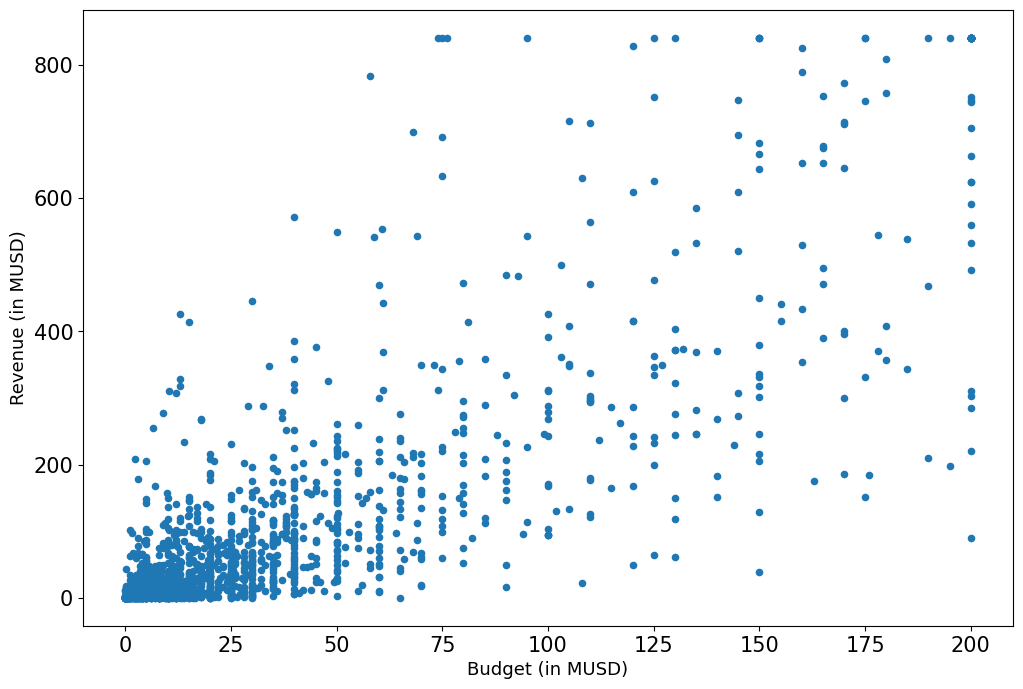

In [107]:
df2.plot(kind = "scatter", x = "budget", y = "revenue", figsize = (12, 8), fontsize = 15)
plt.xlabel("Budget (in MUSD)", fontsize = 13)
plt.ylabel("Revenue (in MUSD)", fontsize = 13)
plt.show()

### Detecting and handling Outliers (Part 2)

In [108]:
df

,title,budget,revenue,vote_average,popularity,belongs_to_collection
0,Ca$h,7.0,0.046488,6.0,9.107829,False
1,Leap Year,19.0,29.922472,6.5,7.432311,False
2,Morning Glory,40.0,58.785180,6.1,10.771255,False
3,Devil,10.0,33.583175,5.8,7.094276,False
4,Tooth Fairy,48.0,112.462508,5.2,6.744680,True
...,...,...,...,...,...,...
1564,Resident Evil: The Final Chapter,40.0,312.242626,5.9,0.755710,True
1565,Railroad Tigers,50.0,102.205175,6.2,3.798504,False
1566,Dangal,10.4,310.000000,8.0,8.792104,False
1567,Live by Night,108.0,22.678555,6.2,19.943930,False


In [109]:
df2

,title,budget,revenue,vote_average,popularity,belongs_to_collection
0,Ca$h,7.0,0.046488,6.0,9.107829,False
1,Leap Year,19.0,29.922472,6.5,7.432311,False
2,Morning Glory,40.0,58.785180,6.1,10.771255,False
3,Devil,10.0,33.583175,5.8,7.094276,False
4,Tooth Fairy,48.0,112.462508,5.2,6.744680,True
...,...,...,...,...,...,...
1564,Resident Evil: The Final Chapter,40.0,312.242626,5.9,0.755710,True
1565,Railroad Tigers,50.0,102.205175,6.2,3.798504,False
1566,Dangal,10.4,310.000000,8.0,8.792104,False
1567,Live by Night,108.0,22.678555,6.2,19.943930,False


In [110]:
model = ols("revenue ~ budget + popularity + vote_average + belongs_to_collection", data = df)

In [111]:
results = model.fit()

In [112]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     980.8
Date:                Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:56:15   Log-Likelihood:                -9623.0
No. Observations:                1569   AIC:                         1.926e+04
Df Residuals:                    1564   BIC:                         1.928e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [113]:
model = ols("revenue ~ budget + popularity + vote_average + belongs_to_collection", data = df2)

In [114]:
results = model.fit()

In [115]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     1175.
Date:                Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:56:15   Log-Likelihood:                -9285.8
No. Observations:                1569   AIC:                         1.858e+04
Df Residuals:                    1564   BIC:                         1.861e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

### Non-Linear Relationships - Transforming Variables

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

__Example 1__

In [169]:
x = np.arange(1, 21)
x

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [170]:
y = 2 * 1/x + 5
y

array([7.        , 6.        , 5.66666667, 5.5       , 5.4       ,
       5.33333333, 5.28571429, 5.25      , 5.22222222, 5.2       ,
       5.18181818, 5.16666667, 5.15384615, 5.14285714, 5.13333333,
       5.125     , 5.11764706, 5.11111111, 5.10526316, 5.1       ])

In [171]:
df = pd.DataFrame(data = {"x" : x, "y": y})

In [172]:
df

,x,y
0,1,7.000000
1,2,6.000000
2,3,5.666667
3,4,5.500000
4,5,5.400000
5,6,5.333333
6,7,5.285714
7,8,5.250000
8,9,5.222222
9,10,5.200000


[]

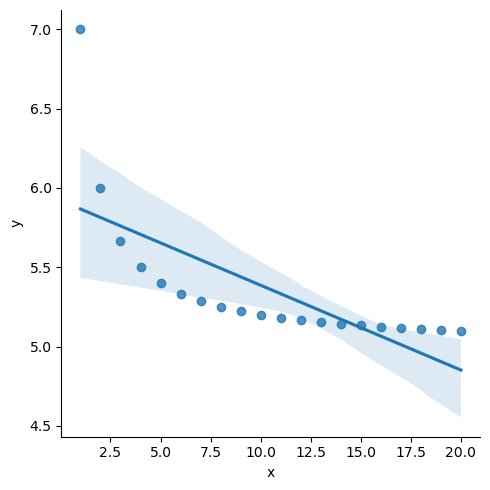

In [173]:
sns.lmplot(x = "x", y = "y", data = df)
plt.plot()

In [174]:
df["invx"] = 1 / df.x

In [175]:
df

,x,y,invx
0,1,7.000000,1.000000
1,2,6.000000,0.500000
2,3,5.666667,0.333333
3,4,5.500000,0.250000
4,5,5.400000,0.200000
5,6,5.333333,0.166667
6,7,5.285714,0.142857
7,8,5.250000,0.125000
8,9,5.222222,0.111111
9,10,5.200000,0.100000


[]

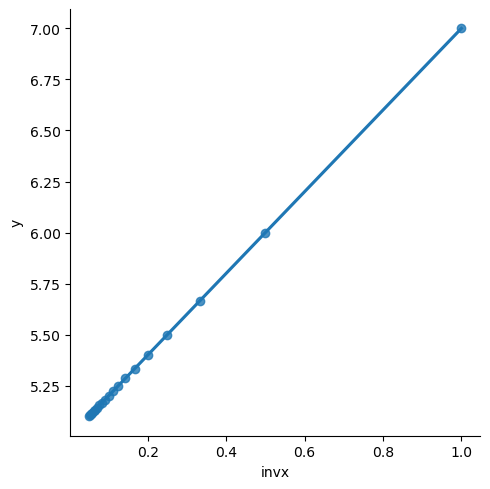

In [176]:
sns.lmplot(x = "invx", y = "y", data = df)
plt.plot()

__Example 2__

In [177]:
x = np.arange(1, 21)
x

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [178]:
y =  x**2
y

array([  1,   4,   9,  16,  25,  36,  49,  64,  81, 100, 121, 144, 169,
       196, 225, 256, 289, 324, 361, 400])

In [179]:
df = pd.DataFrame(data = {"x" : x, "y": y})

In [180]:
df

,x,y
0,1,1
1,2,4
2,3,9
3,4,16
4,5,25
5,6,36
6,7,49
7,8,64
8,9,81
9,10,100


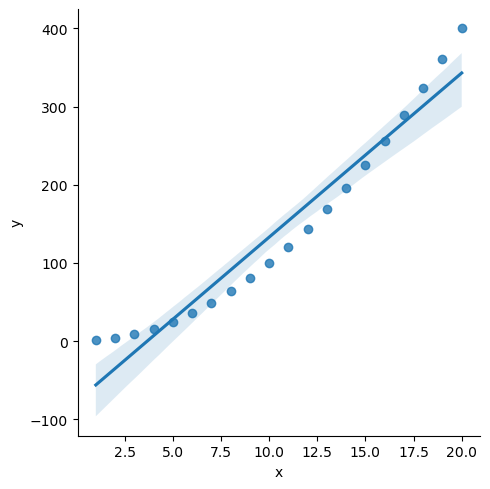

In [181]:
sns.lmplot(x = "x", y = "y", data = df)
plt.show()

In [182]:
df["logx"] = np.log(df.x)
df["logy"] = np.log(df.y)

In [183]:
df

,x,y,logx,logy
0,1,1,0.000000,0.000000
1,2,4,0.693147,1.386294
2,3,9,1.098612,2.197225
3,4,16,1.386294,2.772589
4,5,25,1.609438,3.218876
5,6,36,1.791759,3.583519
6,7,49,1.945910,3.891820
7,8,64,2.079442,4.158883
8,9,81,2.197225,4.394449
9,10,100,2.302585,4.605170


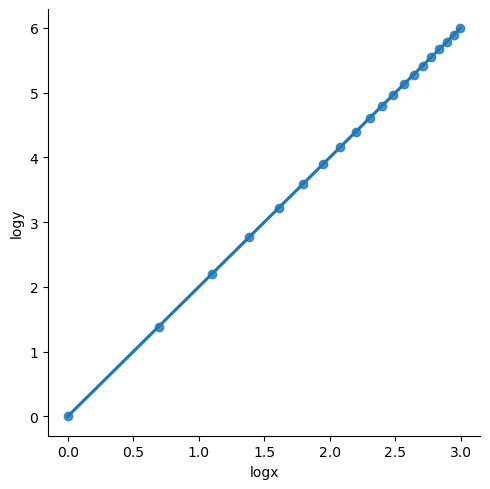

In [184]:
sns.lmplot(x = "logx", y = "logy", data = df)
plt.show()

### Detecting and Handling Multicollinearity

In [185]:
import pandas as pd
from statsmodels.formula.api import ols

In [186]:
df = pd.read_csv("movies_prep.csv")

In [187]:
df

,title,budget,revenue,vote_average,popularity,belongs_to_collection
0,Ca$h,7.0,0.046488,6.0,9.107829,False
1,Leap Year,19.0,29.922472,6.5,7.432311,False
2,Morning Glory,40.0,58.785180,6.1,10.771255,False
3,Devil,10.0,33.583175,5.8,7.094276,False
4,Tooth Fairy,48.0,112.462508,5.2,6.744680,True
...,...,...,...,...,...,...
1564,Resident Evil: The Final Chapter,40.0,312.242626,5.9,0.755710,True
1565,Railroad Tigers,50.0,102.205175,6.2,3.798504,False
1566,Dangal,10.4,310.000000,8.0,8.792104,False
1567,Live by Night,108.0,22.678555,6.2,19.943930,False


In [188]:
df["budget_EUR"] = df.budget / 1.1

In [189]:
df

,title,budget,revenue,vote_average,popularity,belongs_to_collection,budget_EUR
0,Ca$h,7.0,0.046488,6.0,9.107829,False,6.363636
1,Leap Year,19.0,29.922472,6.5,7.432311,False,17.272727
2,Morning Glory,40.0,58.785180,6.1,10.771255,False,36.363636
3,Devil,10.0,33.583175,5.8,7.094276,False,9.090909
4,Tooth Fairy,48.0,112.462508,5.2,6.744680,True,43.636364
...,...,...,...,...,...,...,...
1564,Resident Evil: The Final Chapter,40.0,312.242626,5.9,0.755710,True,36.363636
1565,Railroad Tigers,50.0,102.205175,6.2,3.798504,False,45.454545
1566,Dangal,10.4,310.000000,8.0,8.792104,False,9.454545
1567,Live by Night,108.0,22.678555,6.2,19.943930,False,98.181818


In [190]:
df.budget.corr(df.budget_EUR)

np.float64(1.0)

In [191]:
model = ols("revenue ~ budget + popularity + belongs_to_collection + vote_average", data = df)

In [192]:
results = model.fit()

In [193]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     980.8
Date:                Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:58:06   Log-Likelihood:                -9623.0
No. Observations:                1569   AIC:                         1.926e+04
Df Residuals:                    1564   BIC:                         1.928e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [194]:
df_dumm = pd.get_dummies(df, columns = ["belongs_to_collection"])

In [195]:
df_dumm

,title,budget,revenue,vote_average,popularity,budget_EUR,belongs_to_collection_False,belongs_to_collection_True
0,Ca$h,7.0,0.046488,6.0,9.107829,6.363636,True,False
1,Leap Year,19.0,29.922472,6.5,7.432311,17.272727,True,False
2,Morning Glory,40.0,58.785180,6.1,10.771255,36.363636,True,False
3,Devil,10.0,33.583175,5.8,7.094276,9.090909,True,False
4,Tooth Fairy,48.0,112.462508,5.2,6.744680,43.636364,False,True
...,...,...,...,...,...,...,...,...
1564,Resident Evil: The Final Chapter,40.0,312.242626,5.9,0.755710,36.363636,False,True
1565,Railroad Tigers,50.0,102.205175,6.2,3.798504,45.454545,True,False
1566,Dangal,10.4,310.000000,8.0,8.792104,9.454545,True,False
1567,Live by Night,108.0,22.678555,6.2,19.943930,98.181818,True,False


In [196]:
model = ols("revenue ~ budget + popularity + belongs_to_collection_False + vote_average", data = df_dumm)

In [197]:
results = model.fit()

In [198]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     980.8
Date:                Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:00:34   Log-Likelihood:                -9623.0
No. Observations:                1569   AIC:                         1.926e+04
Df Residuals:                    1564   BIC:                         1.928e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

### Detecting and Correcting Heteroskedasticity

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols

In [148]:
df = pd.read_csv("movies_prep.csv")

In [149]:
df

,title,budget,revenue,vote_average,popularity,belongs_to_collection
0,Ca$h,7.0,0.046488,6.0,9.107829,False
1,Leap Year,19.0,29.922472,6.5,7.432311,False
2,Morning Glory,40.0,58.785180,6.1,10.771255,False
3,Devil,10.0,33.583175,5.8,7.094276,False
4,Tooth Fairy,48.0,112.462508,5.2,6.744680,True
...,...,...,...,...,...,...
1564,Resident Evil: The Final Chapter,40.0,312.242626,5.9,0.755710,True
1565,Railroad Tigers,50.0,102.205175,6.2,3.798504,False
1566,Dangal,10.4,310.000000,8.0,8.792104,False
1567,Live by Night,108.0,22.678555,6.2,19.943930,False


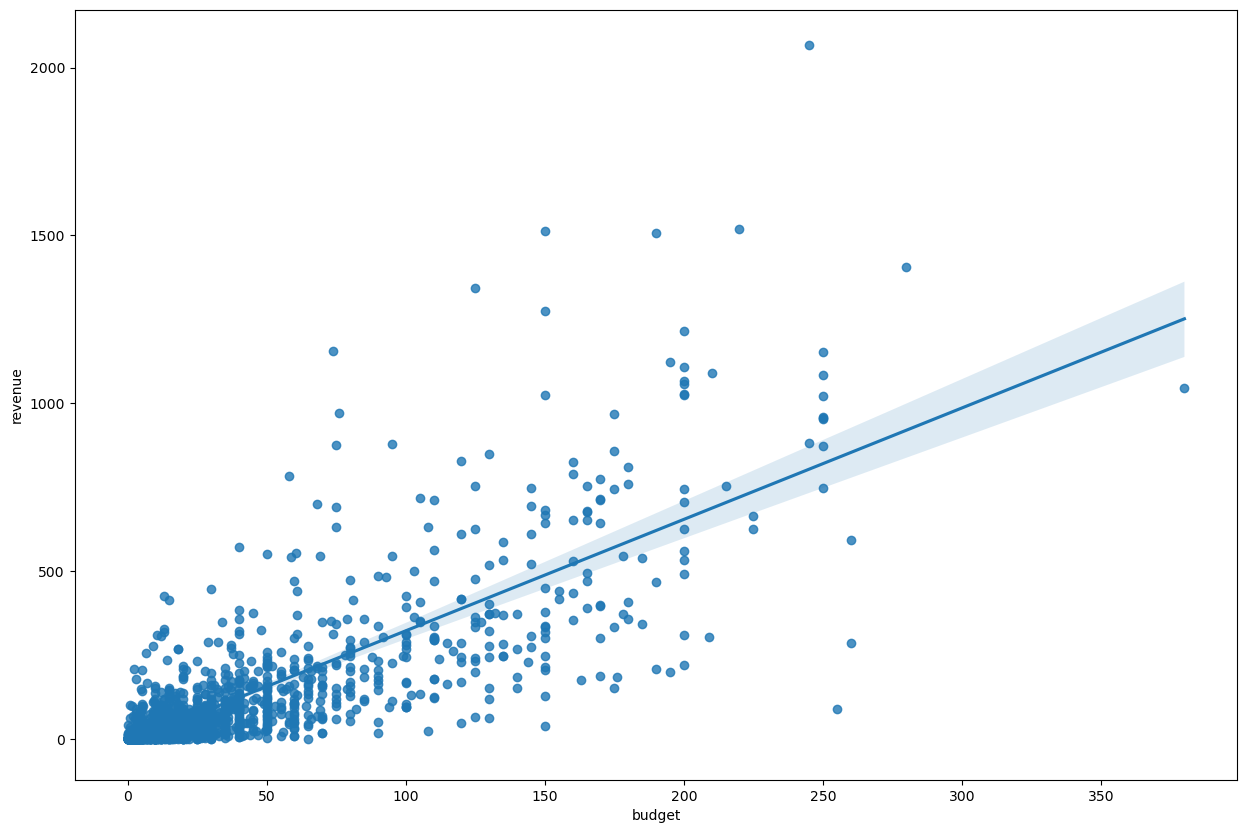

In [150]:
plt.figure(figsize = (15, 10))  
sns.regplot(data = df, x = "budget", y = "revenue")
plt.show()

In [151]:
model = ols("revenue ~ budget" , data = df)

In [152]:
results = model.fit()

In [153]:
df["resid"] = results.resid

In [154]:
df

,title,budget,revenue,vote_average,popularity,belongs_to_collection,resid
0,Ca$h,7.0,0.046488,6.0,9.107829,False,-13.028964
1,Leap Year,19.0,29.922472,6.5,7.432311,False,-22.996594
2,Morning Glory,40.0,58.785180,6.1,10.771255,False,-63.860211
3,Devil,10.0,33.583175,5.8,7.094276,False,10.546820
4,Tooth Fairy,48.0,112.462508,5.2,6.744680,True,-36.745293
...,...,...,...,...,...,...,...
1564,Resident Evil: The Final Chapter,40.0,312.242626,5.9,0.755710,True,189.597235
1565,Railroad Tigers,50.0,102.205175,6.2,3.798504,False,-53.643228
1566,Dangal,10.4,310.000000,8.0,8.792104,False,285.635524
1567,Live by Night,108.0,22.678555,6.2,19.943930,False,-325.747318


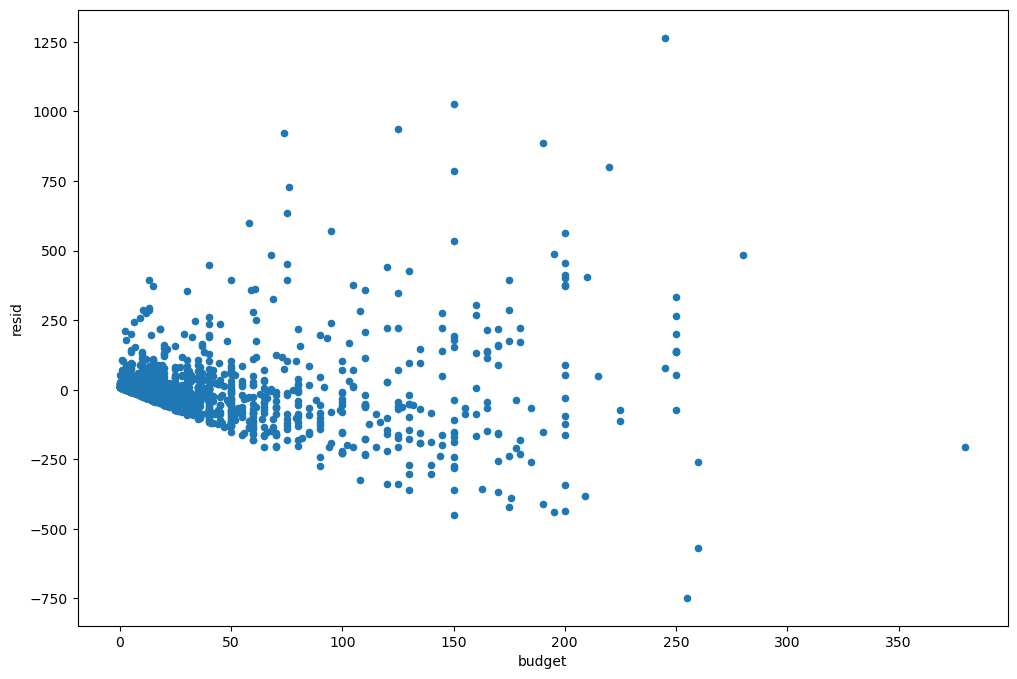

In [155]:
df.plot(kind = "scatter", x = "budget", y = "resid", figsize = (12, 8))
plt.show()

In [156]:
from statsmodels.stats.diagnostic import het_breuschpagan

In [157]:
bp_test = het_breuschpagan(results.resid,  results.model.exog)

In [158]:
bp_test

(np.float64(245.3667009113655),
 np.float64(2.6581398461446378e-55),
 np.float64(290.4804681121605),
 np.float64(6.920918217347147e-60))

In [159]:
labels = ["LM Statistic", "LM-Test p-value", "F-Statistic", "F-Test p-value"]

__H0: Variance of Residuals does not depend on independent variables (Homoskedasticity)__ <br>
__Ha: Variance of Residuals depend on independent variables (Heteroskedasticity)__ 

In [160]:
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(245.3667009113655), 'LM-Test p-value': np.float64(2.6581398461446378e-55), 'F-Statistic': np.float64(290.4804681121605), 'F-Test p-value': np.float64(6.920918217347147e-60)}


In [161]:
model = ols("revenue ~ budget + popularity + belongs_to_collection + vote_average", data = df)

In [162]:
results = model.fit()

In [163]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     980.8
Date:                Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:56:16   Log-Likelihood:                -9623.0
No. Observations:                1569   AIC:                         1.926e+04
Df Residuals:                    1564   BIC:                         1.928e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [164]:
results = model.fit(cov_type = "HC1")

In [165]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     183.2
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          8.09e-129
Time:                        10:56:17   Log-Likelihood:                -9623.0
No. Observations:                1569   AIC:                         1.926e+04
Df Residuals:                    1564   BIC:                         1.928e+04
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

### Serial Correlation (Autocorrelation)

In [166]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols

In [200]:
df = yf.download(["MSFT", "^SP500TR"], start = "2015-12-31", end = "2018-12-31" , auto_adjust = False, multi_level_index = True)

[*********************100%***********************]  2 of 2 completed


In [201]:
df

Price       Adj Close                    Close                     High  \
Ticker           MSFT     ^SP500TR        MSFT     ^SP500TR        MSFT   
Date                                                                      
2015-12-31  48.363499  3821.600098   55.480000  3821.600098   56.189999   
2016-01-04  47.770721  3763.989990   54.799999  3763.989990   54.799999   
2016-01-05  47.988651  3771.570068   55.049999  3771.570068   55.389999   
2016-01-06  47.116932  3723.439941   54.049999  3723.439941   54.400002   
2016-01-07  45.478058  3635.290039   52.169998  3635.290039   53.490002   
...               ...          ...         ...          ...         ...   
2018-12-21  91.501091  4802.509766   98.230003  4802.509766  103.000000   
2018-12-24  87.681961  4672.660156   94.129997  4672.660156   97.970001   
2018-12-26  93.671486  4904.490234  100.559998  4904.490234  100.690002   
2018-12-27  94.249023  4946.939941  101.180000  4946.939941  101.190002   
2018-12-28  93.513161  4941.609863  100.389999  4941.609863  102.410004   

Price                          Low                     Open               \
Ticker         ^SP500TR       MSFT     ^SP500TR        MSFT     ^SP500TR   
Date                                                                       
2015-12-31  3856.370117  55.419998  3821.090088   56.040001  3852.739990   
2016-01-04  3811.739990  53.389999  3721.040039   54.320000  3811.739990   
2016-01-05  3781.270020  54.540001  3748.149902   54.930000  3766.080078   
2016-01-06  3763.550049  53.639999  3702.469971   54.320000  3763.550049   
2016-01-07  3714.290039  52.070000  3627.320068   52.700001  3714.290039   
...                 ...        ...          ...         ...          ...   
2018-12-21  4976.560059  97.459999  4787.040039  101.629997  4899.410156   
2018-12-24  4790.000000  93.980003  4672.660156   97.680000  4770.950195   
2018-12-26  4904.609863  93.959999  4664.089844   95.139999  4696.629883   
2018-12-27  4946.939941  96.400002  4766.390137   99.300003  4854.870117   
2018-12-28  5010.160156  99.519997  4916.640137  102.089996  4967.520020   

Price          Volume           
Ticker           MSFT ^SP500TR  
Date                            
2015-12-31   27334100        0  
2016-01-04   53778000        0  
2016-01-05   34079700        0  
2016-01-06   39518900        0  
2016-01-07   56564900        0  
...               ...      ...  
2018-12-21  111242100        0  
2018-12-24   43935200        0  
2018-12-26   51634800        0  
2018-12-27   49498500        0  
2018-12-28   38196300        0  

[754 rows x 12 columns]

In [202]:
df = df["Adj Close"]

In [203]:
df = df.rename(columns = {"^SP500TR":"SPX"})

In [204]:
df

Ticker,MSFT,SPX
Date,,
2015-12-31,48.363499,3821.600098
2016-01-04,47.770721,3763.989990
2016-01-05,47.988651,3771.570068
2016-01-06,47.116932,3723.439941
2016-01-07,45.478058,3635.290039
...,...,...
2018-12-21,91.501091,4802.509766
2018-12-24,87.681961,4672.660156
2018-12-26,93.671486,4904.490234


In [205]:
ret = df.pct_change().dropna()

In [206]:
ret

Ticker,MSFT,SPX
Date,,
2016-01-04,-0.012257,-0.015075
2016-01-05,0.004562,0.002014
2016-01-06,-0.018165,-0.012761
2016-01-07,-0.034783,-0.023674
2016-01-08,0.003067,-0.010833
...,...,...
2018-12-21,-0.032312,-0.020588
2018-12-24,-0.041739,-0.027038
2018-12-26,0.068310,0.049614


__Regression of Returns (correct__)

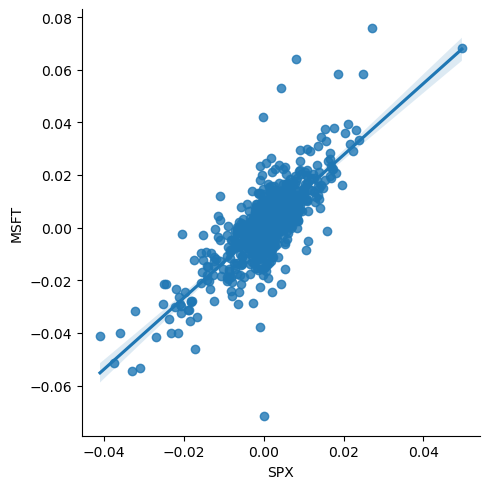

In [207]:
sns.lmplot(x = "SPX", y = "MSFT", data = ret)
plt.show()

In [208]:
model = ols("MSFT ~ SPX", data=ret)

In [209]:
results = model.fit()

In [210]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   MSFT   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     1180.
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          3.43e-156
Time:                        11:02:12   Log-Likelihood:                 2489.8
No. Observations:                 753   AIC:                            -4976.
Df Residuals:                     751   BIC:                            -4966.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0005      0.000      1.444      0.1

In [211]:
results.resid

Date
2016-01-04    0.007750
2016-01-05    0.001359
2016-01-06   -0.001300
2016-01-07   -0.003096
2016-01-08    0.017313
                ...   
2018-12-21   -0.004818
2018-12-24   -0.005484
2018-12-26    0.000456
2018-12-27   -0.006058
2018-12-28   -0.006812
Length: 753, dtype: float64

1. Residuals are __normally distributed__ with mean/expected value == 0

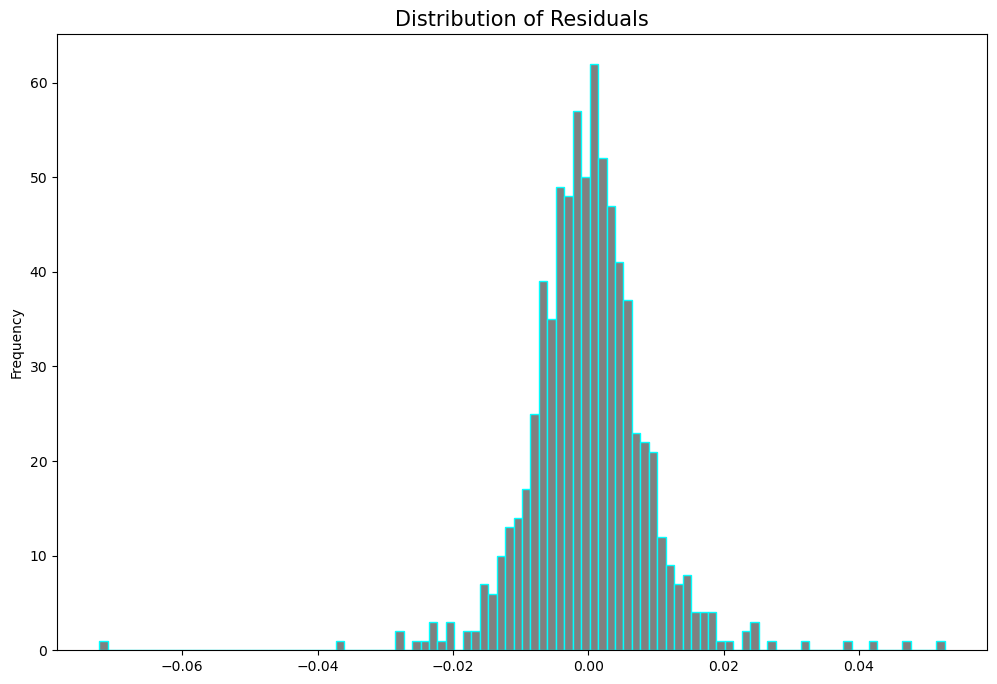

In [213]:
plt.figure(figsize = (12, 8))
results.resid.plot(kind = "hist", bins = 100 , ec= "cyan" , color ="gray")
plt.title("Distribution of Residuals", fontsize = 15)
plt.show()

2. __Residuals are independent__ from each other -> the residual for one observation is not correlated with that of another observation.

In [218]:
pd.options.display.float_format = "{:.4f}".format

In [219]:
results.resid.describe()

count   753.0000
mean      0.0000
std       0.0089
min      -0.0722
25%      -0.0046
50%      -0.0000
75%       0.0045
max       0.0527
dtype: float64

In [261]:
ret["residual"] = results.resid
ret

Ticker,MSFT,SPX,residual
Date,,,
2016-01-04,-0.0123,-0.0151,0.0078
2016-01-05,0.0046,0.0020,0.0014
2016-01-06,-0.0182,-0.0128,-0.0013
2016-01-07,-0.0348,-0.0237,-0.0031
2016-01-08,0.0031,-0.0108,0.0173
...,...,...,...
2018-12-21,-0.0323,-0.0206,-0.0048
2018-12-24,-0.0417,-0.0270,-0.0055
2018-12-26,0.0683,0.0496,0.0005


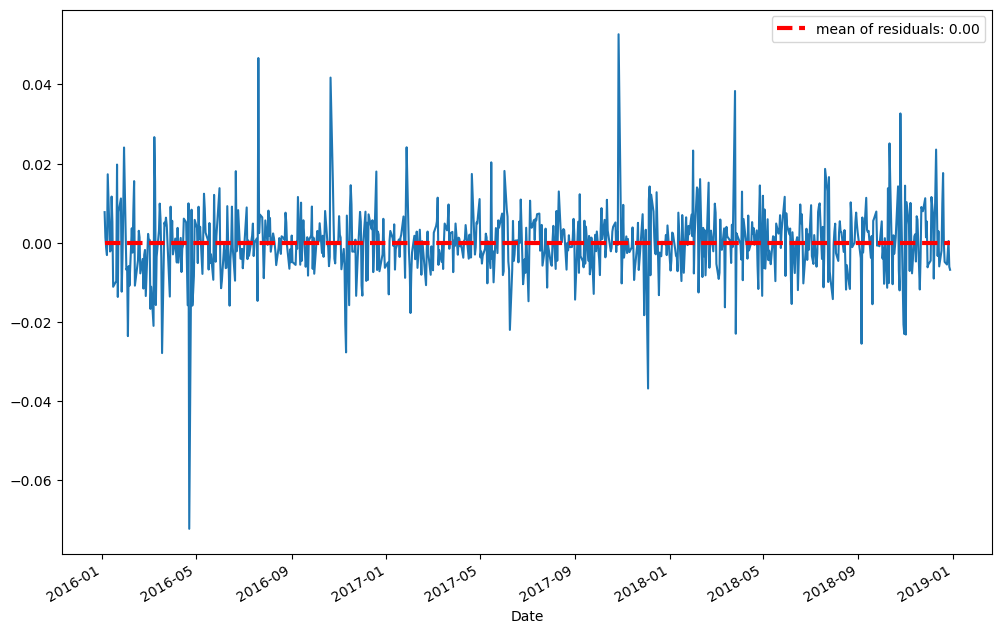

In [224]:
plt.figure(figsize = (12, 8))
results.resid.plot()
plt.hlines(y = results.resid.mean() , xmin = ret.index.min() , xmax = ret.index.max() , color = "red", ls = "--" , lw = 3 , label = f"mean of residuals: {results.resid.mean():.2f}")
plt.legend()
plt.show()

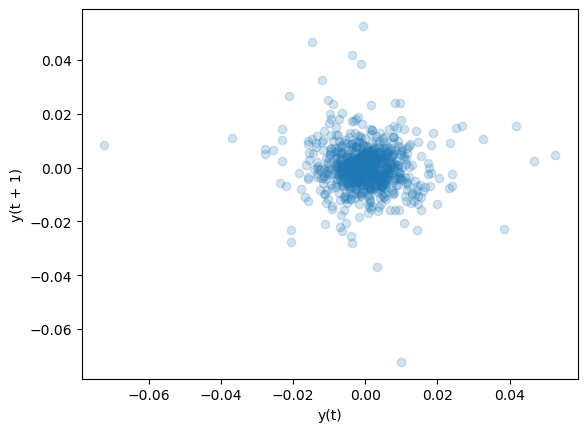

In [238]:
from pandas.plotting import lag_plot
lag_plot(ret["residual"] , alpha = 0.2)
plt.show()

In [240]:
from statsmodels.tsa.stattools import acf

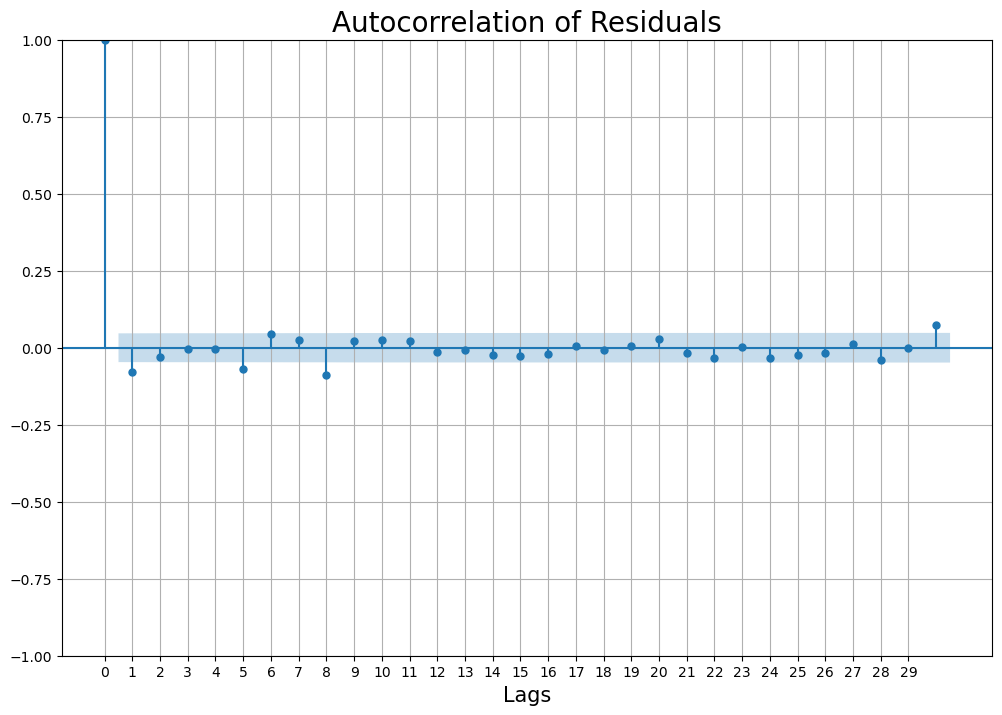

In [259]:
from statsmodels.graphics.tsaplots import plot_acf

fig , ax = plt.subplots()
fig.set_size_inches(12, 8)
plot_acf(ret["residual"] ,alpha = 0.2 , lags = 30 , ax = ax)
ax.set_title("Autocorrelation of Residuals", fontsize = 20)
ax.set_xticks(np.arange(0, 30, 1))
ax.set_xlabel("Lags", fontsize = 15)
ax.grid()
plt.show()

__Regression of Stock Prices (Incorrect)__

In [262]:
df

Ticker,MSFT,SPX
Date,,
2015-12-31,48.3635,3821.6001
2016-01-04,47.7707,3763.9900
2016-01-05,47.9887,3771.5701
2016-01-06,47.1169,3723.4399
2016-01-07,45.4781,3635.2900
...,...,...
2018-12-21,91.5011,4802.5098
2018-12-24,87.6820,4672.6602
2018-12-26,93.6715,4904.4902


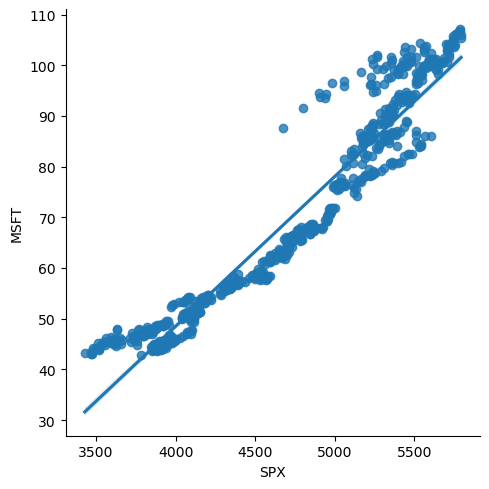

In [263]:
sns.lmplot(x = "SPX", y = "MSFT", data = df)
plt.show()

In [264]:
model = ols("MSFT ~ SPX", data=df)

In [265]:
results = model.fit()

In [266]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   MSFT   R-squared:                       0.920
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     8662.
Date:                Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:25:26   Log-Likelihood:                -2353.3
No. Observations:                 754   AIC:                             4711.
Df Residuals:                     752   BIC:                             4720.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -69.7511      1.505    -46.346      0.0

1. Residuals are __normally distributed__ with mean/expected value == 0

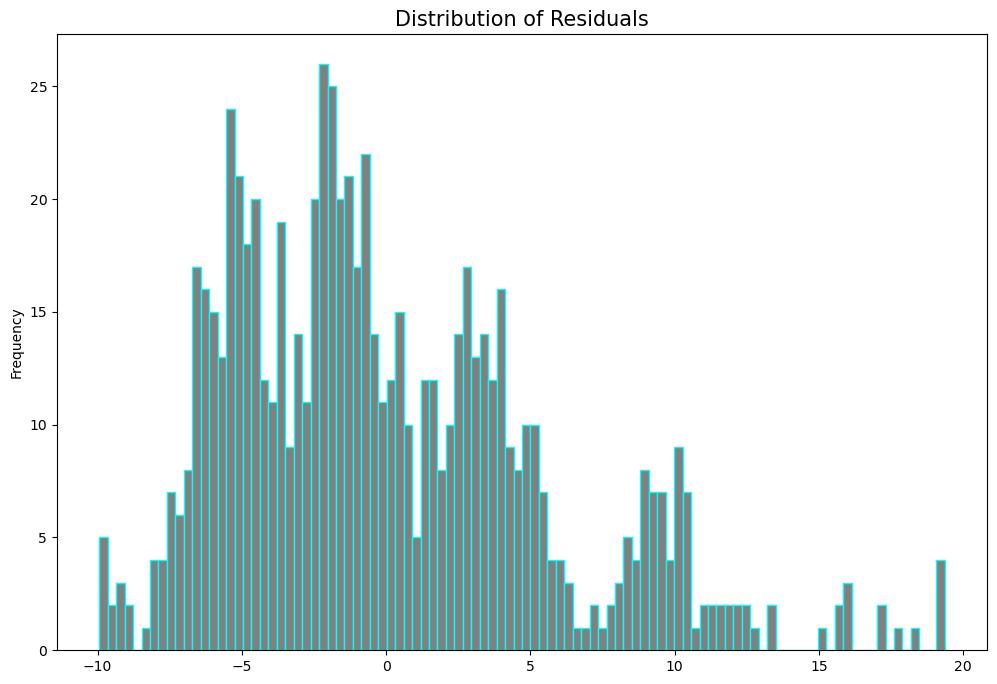

In [268]:
plt.figure(figsize = (12, 8))
results.resid.plot(kind = "hist",ec= "cyan" , color ="gray", bins = 100)
plt.title("Distribution of Residuals", fontsize = 15)
plt.show()

2. __Residuals are independent__ from each other -> the residual for one observation is not correlated with that of another observation.

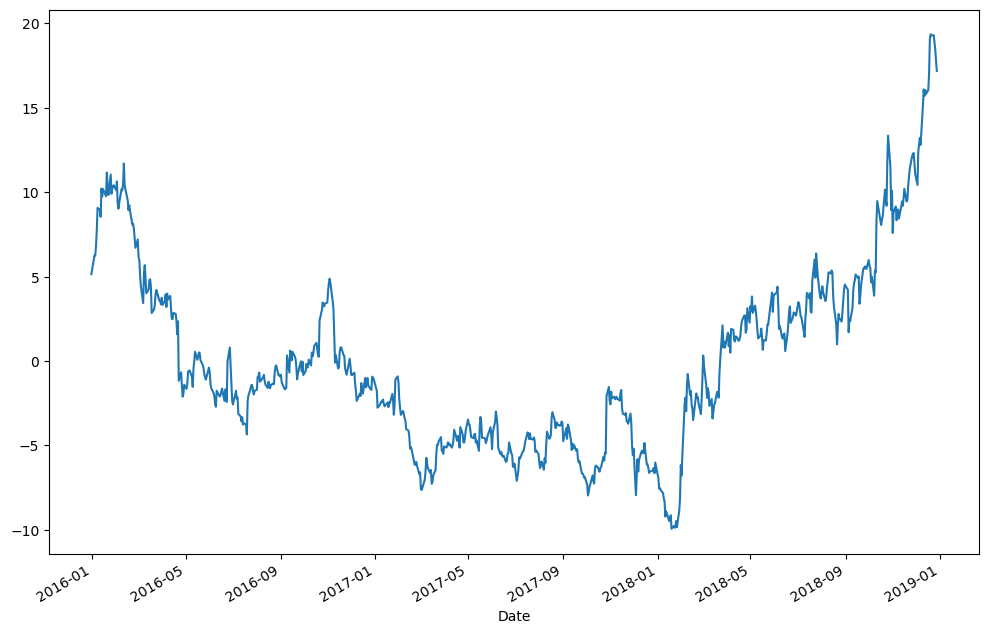

In [269]:
plt.figure(figsize = (12, 8))
results.resid.plot()
plt.show()

In [270]:
lag1 = results.resid.shift()
lag1

Date
2015-12-31       NaN
2016-01-04    5.1451
2016-01-05    6.2553
2016-01-06    6.2492
2016-01-07    6.8002
               ...  
2018-12-21   19.3574
2018-12-24   19.2862
2018-12-26   19.3056
2018-12-27   18.4420
2018-12-28   17.7647
Length: 754, dtype: float64

In [271]:
results.resid.corr(lag1)

np.float64(0.9916092779893574)

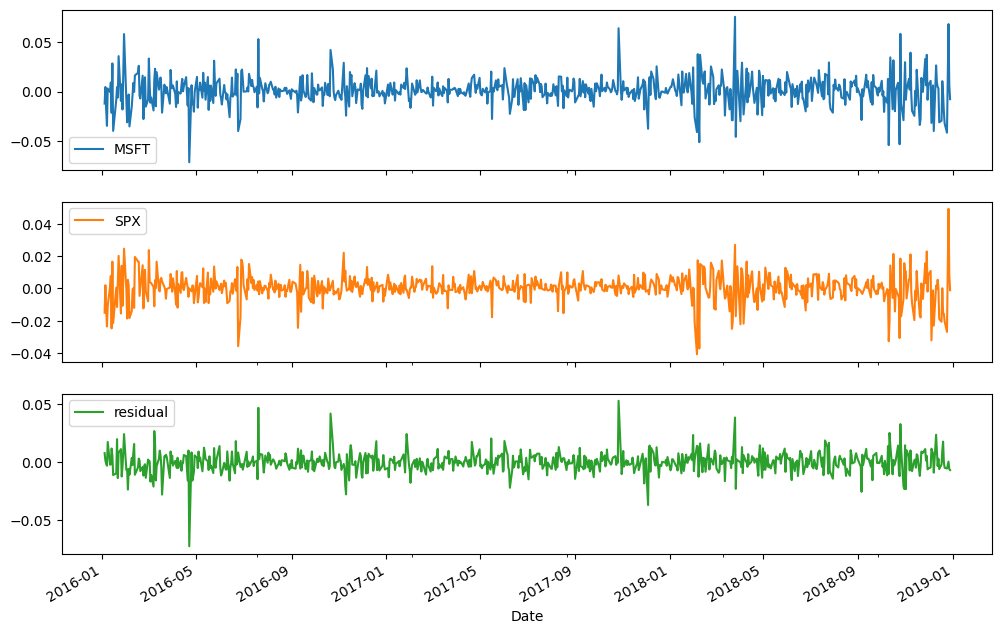

In [272]:
ret.plot(subplots = True, figsize = (12, 8))
plt.show()

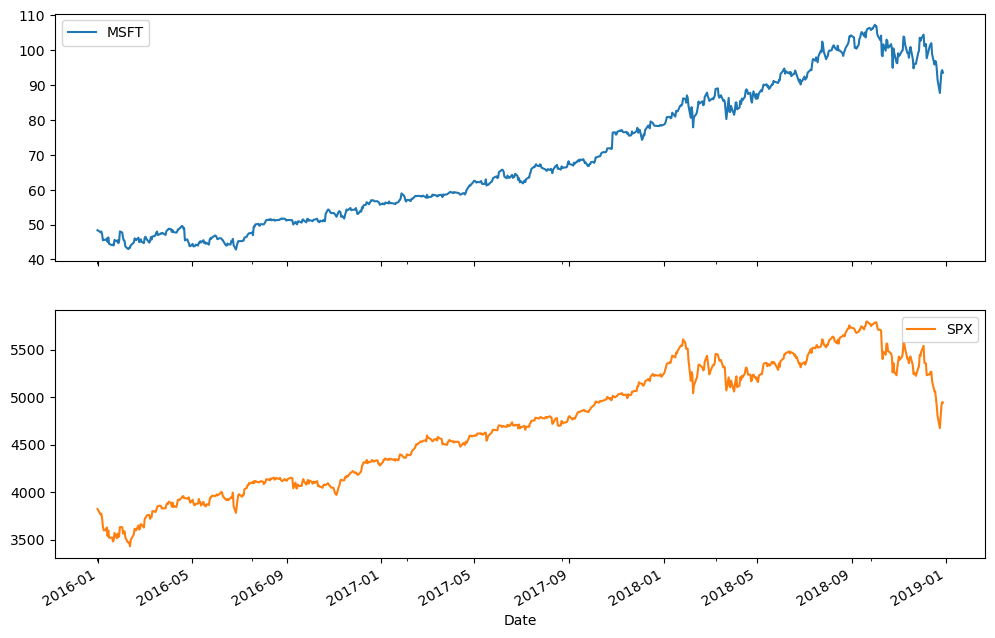

In [273]:
df.plot(subplots = True, figsize = (12, 8))
plt.show()

### Logistic Regression with statsmodels (Part 1)

In [274]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [275]:
titanic = pd.read_csv("titanic.csv")

In [276]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0000,1,0,7.2500,S,NaN
1,1,1,female,38.0000,1,0,71.2833,C,C
2,1,3,female,26.0000,0,0,7.9250,S,NaN
3,1,1,female,35.0000,1,0,53.1000,S,C
4,0,3,male,35.0000,0,0,8.0500,S,NaN
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0000,0,0,13.0000,S,NaN
887,1,1,female,19.0000,0,0,30.0000,S,B
888,0,3,female,NaN,1,2,23.4500,S,NaN
889,1,1,male,26.0000,0,0,30.0000,C,C


In [277]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   deck      203 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


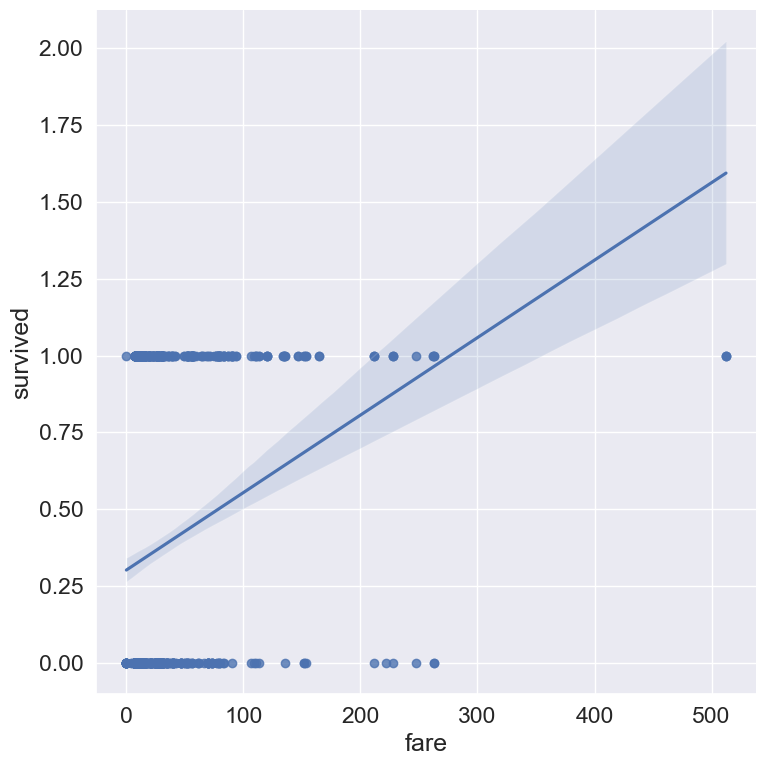

In [278]:
sns.set(font_scale=1.5)
sns.lmplot(data = titanic, x = "fare", y = "survived", aspect= 1, height=8, logistic= False)
plt.show()

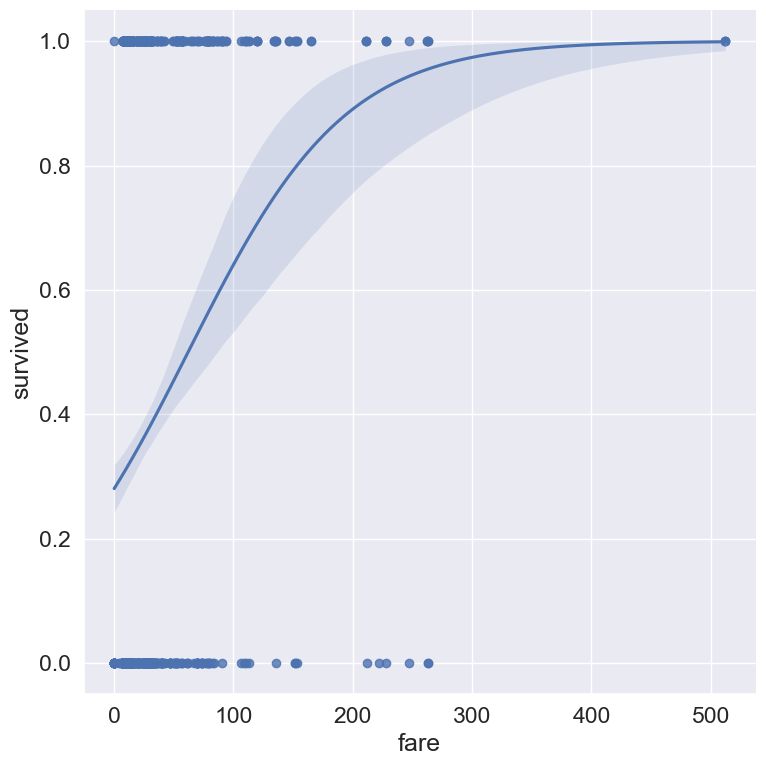

In [279]:
sns.set(font_scale=1.5)
sns.lmplot(data = titanic, x = "fare", y = "survived", aspect= 1, height=8, logistic= True)
plt.show()

In [280]:
from statsmodels.formula.api import logit

In [281]:
model = logit("survived ~ fare", data = titanic)

In [282]:
results = model.fit()

Optimization terminated successfully.
         Current function value: 0.627143
         Iterations 6


In [283]:
print(results.summary())

                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      889
Method:                           MLE   Df Model:                            1
Date:                Tue, 30 Jun 2026   Pseudo R-squ.:                 0.05822
Time:                        11:27:09   Log-Likelihood:                -558.78
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 9.427e-17
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9413      0.095     -9.895      0.000      -1.128      -0.755
fare           0.0152      0.002      6.809      0.000       0.011       0.020


### Logistic Regression with statsmodels (Part 2)

In [284]:
import pandas as pd
from statsmodels.formula.api import logit

In [285]:
titanic = pd.read_csv("titanic.csv")

In [286]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0000,1,0,7.2500,S,NaN
1,1,1,female,38.0000,1,0,71.2833,C,C
2,1,3,female,26.0000,0,0,7.9250,S,NaN
3,1,1,female,35.0000,1,0,53.1000,S,C
4,0,3,male,35.0000,0,0,8.0500,S,NaN
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0000,0,0,13.0000,S,NaN
887,1,1,female,19.0000,0,0,30.0000,S,B
888,0,3,female,NaN,1,2,23.4500,S,NaN
889,1,1,male,26.0000,0,0,30.0000,C,C


In [287]:
titanic.age.fillna(titanic.age.mean(), inplace = True)

C:\Users\ahmad\AppData\Local\Temp\ipykernel_21912\365094017.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic.age.fillna(titanic.age.mean(), inplace = True)


In [288]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   deck      203 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [289]:
titanic = pd.get_dummies(titanic, columns = ["sex", "pclass"], drop_first=False)

In [290]:
titanic

,survived,age,sibsp,parch,fare,embarked,deck,sex_female,sex_male,pclass_1,pclass_2,pclass_3
0,0,22.0000,1,0,7.2500,S,NaN,False,True,False,False,True
1,1,38.0000,1,0,71.2833,C,C,True,False,True,False,False
2,1,26.0000,0,0,7.9250,S,NaN,True,False,False,False,True
3,1,35.0000,1,0,53.1000,S,C,True,False,True,False,False
4,0,35.0000,0,0,8.0500,S,NaN,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,27.0000,0,0,13.0000,S,NaN,False,True,False,True,False
887,1,19.0000,0,0,30.0000,S,B,True,False,True,False,False
888,0,29.6991,1,2,23.4500,S,NaN,True,False,False,False,True
889,1,26.0000,0,0,30.0000,C,C,False,True,True,False,False


In [291]:
titanic["Rel"] = titanic.sibsp + titanic.parch 

In [292]:
titanic

,survived,age,sibsp,parch,fare,embarked,deck,sex_female,sex_male,pclass_1,pclass_2,pclass_3,Rel
0,0,22.0000,1,0,7.2500,S,NaN,False,True,False,False,True,1
1,1,38.0000,1,0,71.2833,C,C,True,False,True,False,False,1
2,1,26.0000,0,0,7.9250,S,NaN,True,False,False,False,True,0
3,1,35.0000,1,0,53.1000,S,C,True,False,True,False,False,1
4,0,35.0000,0,0,8.0500,S,NaN,False,True,False,False,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,27.0000,0,0,13.0000,S,NaN,False,True,False,True,False,0
887,1,19.0000,0,0,30.0000,S,B,True,False,True,False,False,0
888,0,29.6991,1,2,23.4500,S,NaN,True,False,False,False,True,3
889,1,26.0000,0,0,30.0000,C,C,False,True,True,False,False,0


In [293]:
model = logit("survived ~ fare + age + sex_male + pclass_1 + pclass_3 + Rel", data = titanic)

In [294]:
results = model.fit()

Optimization terminated successfully.
         Current function value: 0.443547
         Iterations 6


In [295]:
print(results.summary())

                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      884
Method:                           MLE   Df Model:                            6
Date:                Tue, 30 Jun 2026   Pseudo R-squ.:                  0.3339
Time:                        11:35:32   Log-Likelihood:                -395.20
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 1.786e-82
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.8093      0.347      8.085      0.000       2.128       3.490
sex_male[T.True]    -2.7759      0.199    -13.980      0.000      -3.165      -2.387
pclass_1[T.True]     1.0003 

Since our dependent variable is `survived`, a negative coefficient of an independent variable means the variable is associated with lower probability of survival.